In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from IPython.display import Image,display
from typing import TypedDict
import os

In [28]:
model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="nvidia/nemotron-3.5-lightning:free"
)
api_key="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"

In [19]:
prompt=PromptTemplate(
    template="""Answer the qiven question:
    {ques}""",
    input_variables=["ques"]
)

In [7]:
parser=StrOutputParser()

In [8]:
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    bmi_status:str
    status_suggestion:str

In [9]:
graph=StateGraph(BMIState)

In [20]:
def calculate_bmi(state:BMIState)->BMIState:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)
    state['bmi']=round(bmi, 2)
    return state

In [21]:
def bmi_status(state:BMIState)->BMIState:
    bmi=state['bmi']
    ques=f"Depending upon the given value of bmi:{bmi} determine wheter the person is underweight, fit or overweight"
    chain=prompt | model | parser
    state['bmi_status']= chain.invoke({'ques':ques})
    return state

In [22]:
def status_suggestion(state:BMIState)->BMIState:
    bmi_status=state['bmi_status']
    status_suggestion=f"Depending upon the given status of bmi:{bmi_status} among underweight, fit or overweight, determine the type of dite a person can have. Make a diet plan."
    chain=prompt | model | parser
    state['status_suggestion']= chain.invoke({'ques':status_suggestion})
    return state

In [13]:
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('bmi_status',bmi_status)
graph.add_node('status_suggestion',status_suggestion)


In [14]:
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','bmi_status')
graph.add_edge('bmi_status','status_suggestion')
graph.add_edge('status_suggestion',END)

In [23]:
# Execute the workflow
workflow=graph.compile()
final_graph = workflow.invoke({
    "weight_kg": 80,
    "height_m": 1.74
})

print(final_graph)

{'weight_kg': 80, 'height_m': 1.74, 'bmi': 26.42, 'bmi_status': 'Based on the standard BMI classification:\n\n- **Underweight:** BMI < 18.5  \n- **Normal weight / "fit":** BMI 18.5 – 24.9  \n- **Overweight:** BMI 25 – 29.9  \n- **Obese:** BMI ≥ 30  \n\nYour BMI of **26.42** falls within the **overweight** range (25 – 29.9). If "fit" is being used colloquially to mean healthy or normal weight, this BMI exceeds that range. \n\nLet me know if you\'d like help interpreting this in context of muscle mass, body composition, or goal setting!', 'status_suggestion': '**BMI Status:** Your BMI of 26.42 falls squarely into the **overweight** range (25.0–29.9).  \n**Diet Approach for Overweight:** The goal is typically a modest, sustainable calorie deficit (≈300–500 kcal/day), prioritizing nutrient-dense foods, adequate protein to preserve lean mass, high fiber for satiety, and balanced macros. This supports steady fat loss while maintaining energy and muscle tone, especially if paired with resista

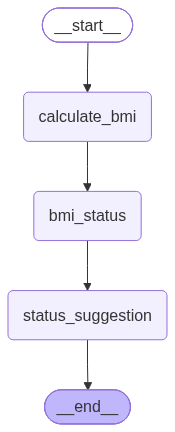

In [18]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [27]:
print(final_graph['bmi_status'])

Based on the standard BMI classification:

- **Underweight:** BMI < 18.5  
- **Normal weight / "fit":** BMI 18.5 – 24.9  
- **Overweight:** BMI 25 – 29.9  
- **Obese:** BMI ≥ 30  

Your BMI of **26.42** falls within the **overweight** range (25 – 29.9). If "fit" is being used colloquially to mean healthy or normal weight, this BMI exceeds that range. 

Let me know if you'd like help interpreting this in context of muscle mass, body composition, or goal setting!


In [26]:
print(final_graph['status_suggestion'])

**BMI Status:** Your BMI of 26.42 falls squarely into the **overweight** range (25.0–29.9).  
**Diet Approach for Overweight:** The goal is typically a modest, sustainable calorie deficit (≈300–500 kcal/day), prioritizing nutrient-dense foods, adequate protein to preserve lean mass, high fiber for satiety, and balanced macros. This supports steady fat loss while maintaining energy and muscle tone, especially if paired with resistance training or increased daily movement.

Below is a **general daily diet template** tailored for someone in the overweight BMI range. Calories are estimated around 1,700–1,900 kcal (adjustable based on age, sex, height, activity level, and goals). Always consult a healthcare/professional nutritionist for personalized advice.

---

### 🍎 Sample Daily Meal Plan (≈1,800 kcal)

**Breakfast (~400 kcal)**  
- 2 large eggs scrambled with spinach & mushrooms  
- 1 slice whole-grain toast  
- 1 small avocado (or ¼ avocado)  
- Black coffee/tea (no sugar) or water

**